In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.1
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
BASE_DIR = Path("../Dados")
TREINO_DIR = BASE_DIR / "Treino"
VALIDACAO_DIR = BASE_DIR / "Validacao"
TESTE_DIR = BASE_DIR / "Teste"

CLASSES = ["nowildfire", "wildfire"]

for d in [TREINO_DIR, VALIDACAO_DIR, TESTE_DIR]:
    assert d.exists(), f"Não encontrei: {d}"
    print(f"✓ {d}")

✓ ../Dados/Treino
✓ ../Dados/Validacao
✓ ../Dados/Teste


In [3]:
def contar_imagens(base_dir):
    return {classe: len(list((base_dir / classe).glob("*"))) for classe in CLASSES}

dados_contagem = {
    "Treino": contar_imagens(TREINO_DIR),
    "Validacao": contar_imagens(VALIDACAO_DIR),
    "Teste": contar_imagens(TESTE_DIR),
}

df_contagem = pd.DataFrame(dados_contagem).T
df_contagem["total"] = df_contagem.sum(axis=1)
df_contagem.loc["TOTAL"] = df_contagem.sum()

print(df_contagem)

           nowildfire  wildfire  total
Treino          14500     15750  30250
Validacao        2820      3480   6300
Teste            2820      3480   6300
TOTAL           20140     22710  42850


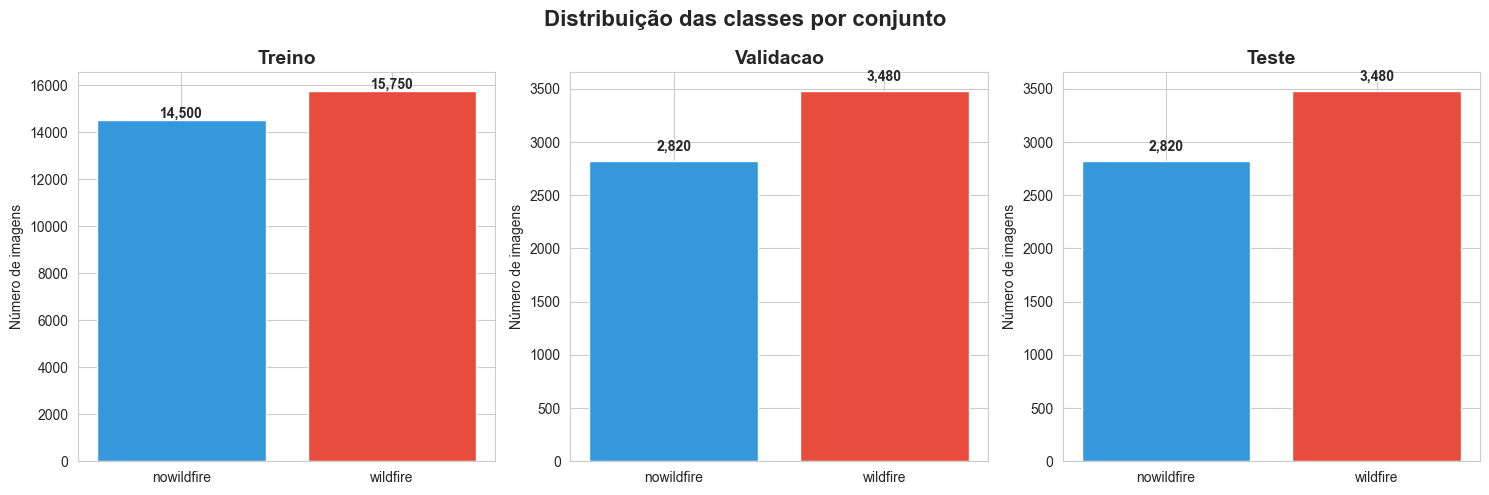

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (conjunto, contagens) in zip(axes, dados_contagem.items()):
    ax.bar(contagens.keys(), contagens.values(), color=["#3498db", "#e74c3c"])
    ax.set_title(f"{conjunto}", fontsize=14, fontweight="bold")
    ax.set_ylabel("Número de imagens")
    for i, (k, v) in enumerate(contagens.items()):
        ax.text(i, v + 100, f"{v:,}", ha="center", fontweight="bold")

plt.suptitle("Distribuição das classes por conjunto", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/distribuicao_classes.png", dpi=100, bbox_inches="tight")
plt.show()

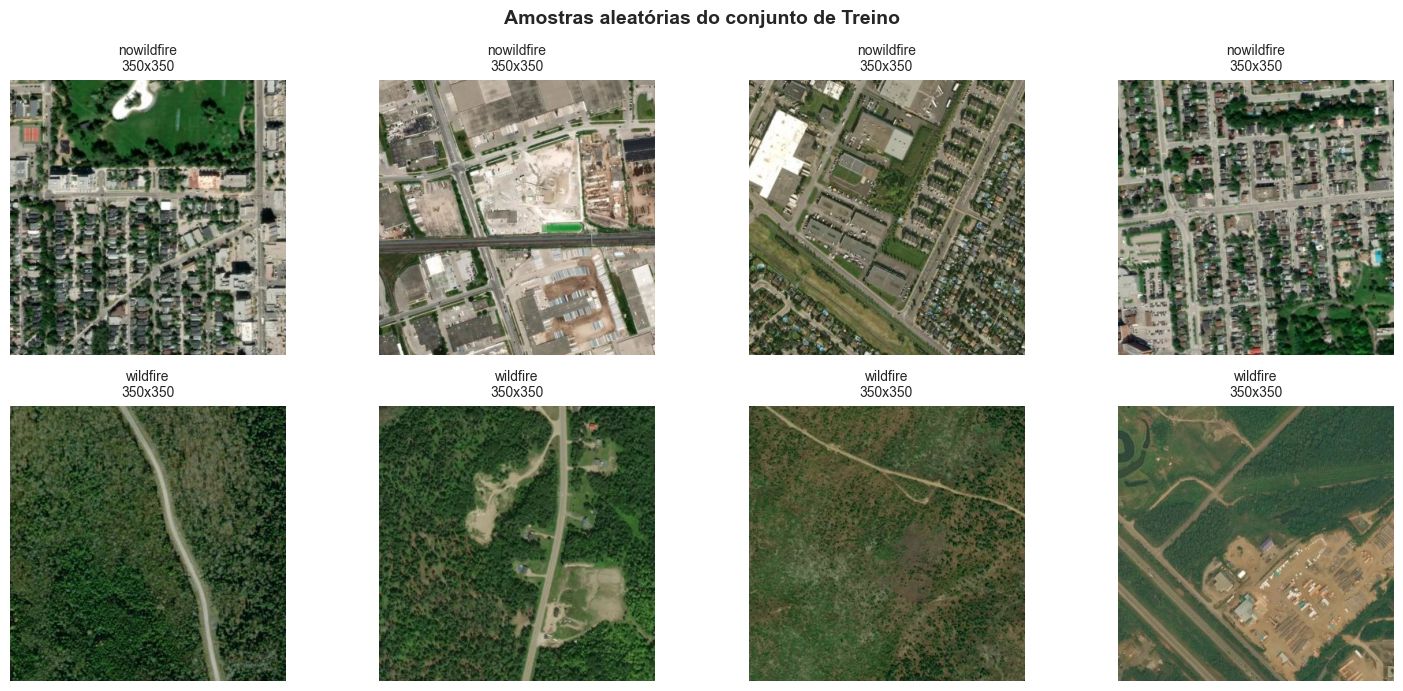

In [5]:
def mostrar_amostras(base_dir, n_amostras=4):
    fig, axes = plt.subplots(2, n_amostras, figsize=(15, 7))
    
    for i, classe in enumerate(CLASSES):
        pasta = base_dir / classe
        arquivos = random.sample(list(pasta.glob("*")), n_amostras)
        
        for j, arq in enumerate(arquivos):
            img = Image.open(arq)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{classe}\n{img.size[0]}x{img.size[1]}", fontsize=10)
            axes[i, j].axis("off")
    
    plt.suptitle("Amostras aleatórias do conjunto de Treino", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../reports/amostras_imagens.png", dpi=100, bbox_inches="tight")
    plt.show()

mostrar_amostras(TREINO_DIR)

In [6]:
def analisar_dimensoes(base_dir, n_sample=500):
    """Analisa dimensões de uma amostra de imagens (rápido)."""
    dimensoes = []
    for classe in CLASSES:
        arquivos = list((base_dir / classe).glob("*"))
        sample = random.sample(arquivos, min(n_sample, len(arquivos)))
        for arq in sample:
            with Image.open(arq) as img:
                dimensoes.append({"classe": classe, "largura": img.size[0], "altura": img.size[1], "modo": img.mode})
    return pd.DataFrame(dimensoes)

df_dim = analisar_dimensoes(TREINO_DIR)
print("Estatísticas das dimensões (amostra de 500 por classe):")
print(df_dim[["largura", "altura"]].describe())
print("\nModos de cor encontrados:")
print(df_dim["modo"].value_counts())

Estatísticas das dimensões (amostra de 500 por classe):
       largura  altura
count   1000.0  1000.0
mean     350.0   350.0
std        0.0     0.0
min      350.0   350.0
25%      350.0   350.0
50%      350.0   350.0
75%      350.0   350.0
max      350.0   350.0

Modos de cor encontrados:
modo
RGB    1000
Name: count, dtype: int64


In [ ]:

print("RESUMO DO EDA")
print(f"""
 Dataset: Wildfire Prediction (Satellite Images)
 Total de imagens: {df_contagem.loc['TOTAL', 'total']:,}
 Classes: {CLASSES} (binária)
 Distribuição: balanceada (~53% wildfire / ~47% nowildfire)
 Split definido pelo autor: ~70% treino / 15% val / 15% teste
 Dimensões: {df_dim['largura'].mode()[0]}x{df_dim['altura'].mode()[0]} pixels (consistente)
 Canais: {df_dim['modo'].mode()[0]} (RGB)

PRÓXIMOS PASSOS:
- Resize para 64x64 (padrão para CNNs leves e rápido no M4)
- Normalização: dividir pixels por 255.0
- Data augmentation no Modelo 2 (flip, rotation, zoom)
""")

RESUMO DO EDA

✅ Dataset: Wildfire Prediction (Satellite Images)
✅ Total de imagens: 42,850
✅ Classes: ['nowildfire', 'wildfire'] (binária)
✅ Distribuição: balanceada (~53% wildfire / ~47% nowildfire)
✅ Split definido pelo autor: ~70% treino / 15% val / 15% teste
✅ Dimensões: 350x350 pixels (consistente)
✅ Canais: RGB (RGB)

PRÓXIMOS PASSOS:
- Resize para 64x64 (padrão para CNNs leves e rápido no M4)
- Normalização: dividir pixels por 255.0
- Data augmentation no Modelo 2 (flip, rotation, zoom)

